<a href="https://colab.research.google.com/github/thaiyalvishu97/MyProjects/blob/main/Project_16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Project_16 - Healthy Eating Cluster

In [7]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv('healthy_eating_dataset.csv')

In [9]:
df.isnull().sum()

,0
meal_id,0
meal_name,0
cuisine,0
meal_type,0
diet_type,0
calories,0
protein_g,0
carbs_g,0
fat_g,0
fiber_g,0


In [10]:
le = LabelEncoder()
df['meal_name'] = le.fit_transform(df['meal_name'])
df['cuisine'] = le.fit_transform(df['cuisine'])
df['meal_type'] = le.fit_transform(df['meal_type'])
df['diet_type'] = le.fit_transform(df['diet_type'])
df['cooking_method'] = le.fit_transform(df['cooking_method'])

In [11]:
df

,meal_id,meal_name,cuisine,meal_type,diet_type,calories,protein_g,carbs_g,fat_g,fiber_g,sugar_g,sodium_mg,cholesterol_mg,serving_size_g,cooking_method,prep_time_min,cook_time_min,rating,is_healthy,image_url
0,1,741,2,2,1,737,52.4,43.9,34.3,16.8,42.9,2079,91,206,3,47,56,4.4,0,https://example.com/images/meal_1.jpg
1,2,670,6,2,3,182,74.7,144.4,0.1,22.3,38.6,423,7,317,5,51,34,2.4,0,https://example.com/images/meal_2.jpg
2,3,11,2,3,3,881,52.9,97.3,18.8,20.0,37.5,2383,209,395,1,58,29,4.3,0,https://example.com/images/meal_3.jpg
3,4,72,6,3,1,427,17.5,73.1,7.6,9.8,41.7,846,107,499,3,14,81,4.6,0,https://example.com/images/meal_4.jpg
4,5,1142,7,2,4,210,51.6,104.3,26.3,24.8,18.2,1460,42,486,4,47,105,4.3,0,https://example.com/images/meal_5.jpg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1996,22,5,2,1,163,16.0,48.1,3.6,26.6,40.9,984,155,447,3,37,71,1.3,0,https://example.com/images/meal_1996.jpg
1996,1997,831,5,3,0,177,79.5,24.4,12.9,27.1,13.6,1612,271,211,5,60,9,1.5,1,https://example.com/images/meal_1997.jpg
1997,1998,1399,2,2,0,419,31.8,42.9,42.7,9.4,29.1,1192,201,248,5,50,95,3.8,0,https://example.com/images/meal_1998.jpg
1998,1999,129,0,1,1,1123,6.9,119.6,23.1,0.8,17.7,360,146,342,2,15,20,4.2,0,https://example.com/images/meal_1999.jpg


In [18]:
X = df.iloc[:,4:18]
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

In [19]:
X_pca

array([[ 819.55105693,  107.52012744],
       [-822.39497689, -488.79925187],
       [1119.32931738,  258.85792373],
       ...,
       [ -59.4199446 , -232.62127341],
       [-909.01907238,  450.28035916],
       [-851.20836369, -330.40920314]])

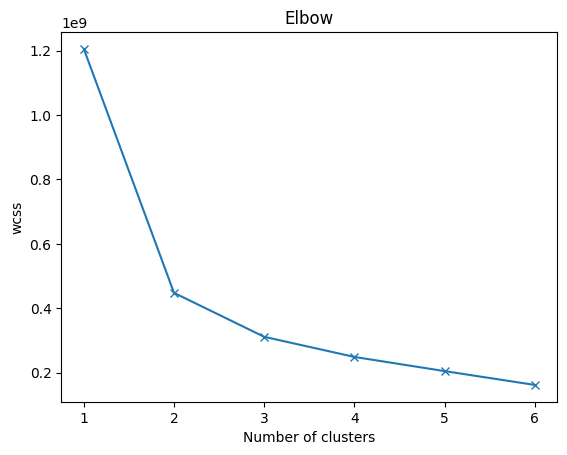

In [20]:
wcss = []
for k in range(1,7):
  km = KMeans(n_clusters=k,random_state=42)
  km.fit(X_pca)
  wcss.append(km.inertia_)
plt.plot(range(1,7),wcss,marker='x')
plt.title("Elbow")
plt.xlabel("Number of clusters")
plt.ylabel("wcss")
plt.show()

In [21]:
model = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
model.fit(X_pca)
y = model.predict(X_pca)

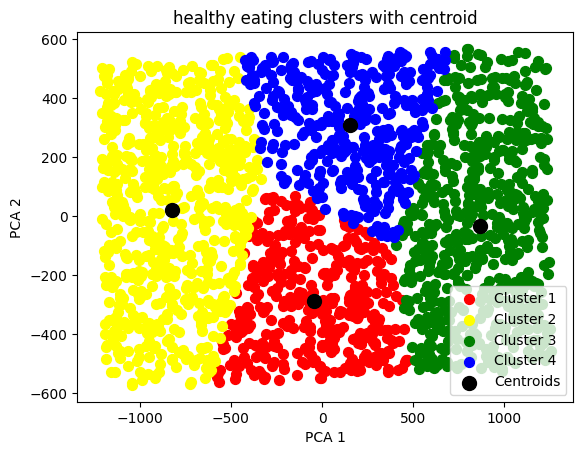

In [22]:
plt.scatter(X_pca[y==0,0],X_pca[y==0,1],s=50,c='red', label='Cluster 1')
plt.scatter(X_pca[y==1,0],X_pca[y==1,1],s=50,c='yellow', label='Cluster 2')
plt.scatter(X_pca[y==2,0],X_pca[y==2,1],s=50,c='green', label='Cluster 3')
plt.scatter(X_pca[y==3,0],X_pca[y==3,1],s=50,c='blue', label='Cluster 4')
plt.scatter(model.cluster_centers_[:,0],model.cluster_centers_[:,1],s=100,c='black',label='Centroids')
plt.title('healthy eating clusters with centroid')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')  #0,1,2  clusters #0,1 pca
plt.legend()
plt.show()
